Exemplo 1: Determinando distâncias cosmológicas em uma Cosmologia fiducial. 

In [4]:
from numcosmo_py import Nc, Ncm
import matplotlib.pyplot as plt
Ncm.cfg_init() #Deve ser feito antes de qualquer função da biblioteca NumCosmo

plt.rcdefaults()
plt.rcParams['figure.dpi'] = 150  #Qualidade do plot

Definindo a função distância e determinando a Cosmologia fiducial:

In [5]:
def distance() -> None:
    cosmo = Nc.HICosmoDEXcdm(massnu_length=0) #Sem neutrinos massivos
    cosmo.set_reparam(Nc.HICosmoDEReparamCMB.new(cosmo.len()))

    dist = Nc.Distance.new(6.0) #Otimizado até redshift z=6

    #Cosmologia fiducial

    cosmo.props.H0 = 70
    cosmo.props.Omegab = 0.05
    cosmo.props.Omegac = 0.26
    cosmo.props.Omegax = 0.68
    cosmo.props.Tgamma0 = 2.72
    cosmo.props.w = -1.0

    print("Parâmetros da Cosmologia Fiducial:")
    cosmo.params_log_all()

    dist.prepare(cosmo) 

    N = 100
    RH_Mpc = cosmo.RH_Mpc() #Hubble Radius c/H_0 para Mpc

    #listas para plot 
    z_list = []
    dc_list = []
    da_list = []
    dl_list = []

    #Loop em função do redshift z:
    
    for i in range(0, N):

        z = 6.0 / (N - 1.0) * i

        Dc = dist.comoving(cosmo, z)  # Distância comóvel
        d_A = Dc / (1.0 + z)  # Distância angular pela definição
        d_L = Dc * (1.0 + z)  # Distância de luminosidade pela definição
        Luminosity = dist.luminosity(cosmo,z) # Distância de luminosidade 
        Angular = dist.angular_diameter(cosmo,z) # Distância angular


        z_list.append(z)
        dc_list.append(Dc)
        da_list.append(Angular)
        dl_list.append(Luminosity)
    
    return z_list, dc_list, da_list, dl_list, cosmo.props.H0, cosmo.props.Omegab, cosmo.props.Omegac, cosmo.props.Omegax

Plotando:

Parâmetros da Cosmologia Fiducial:
                      70                  0.1274    0.009915305421953291                    2.72                    0.24                   3.046                  0.0245                      -1


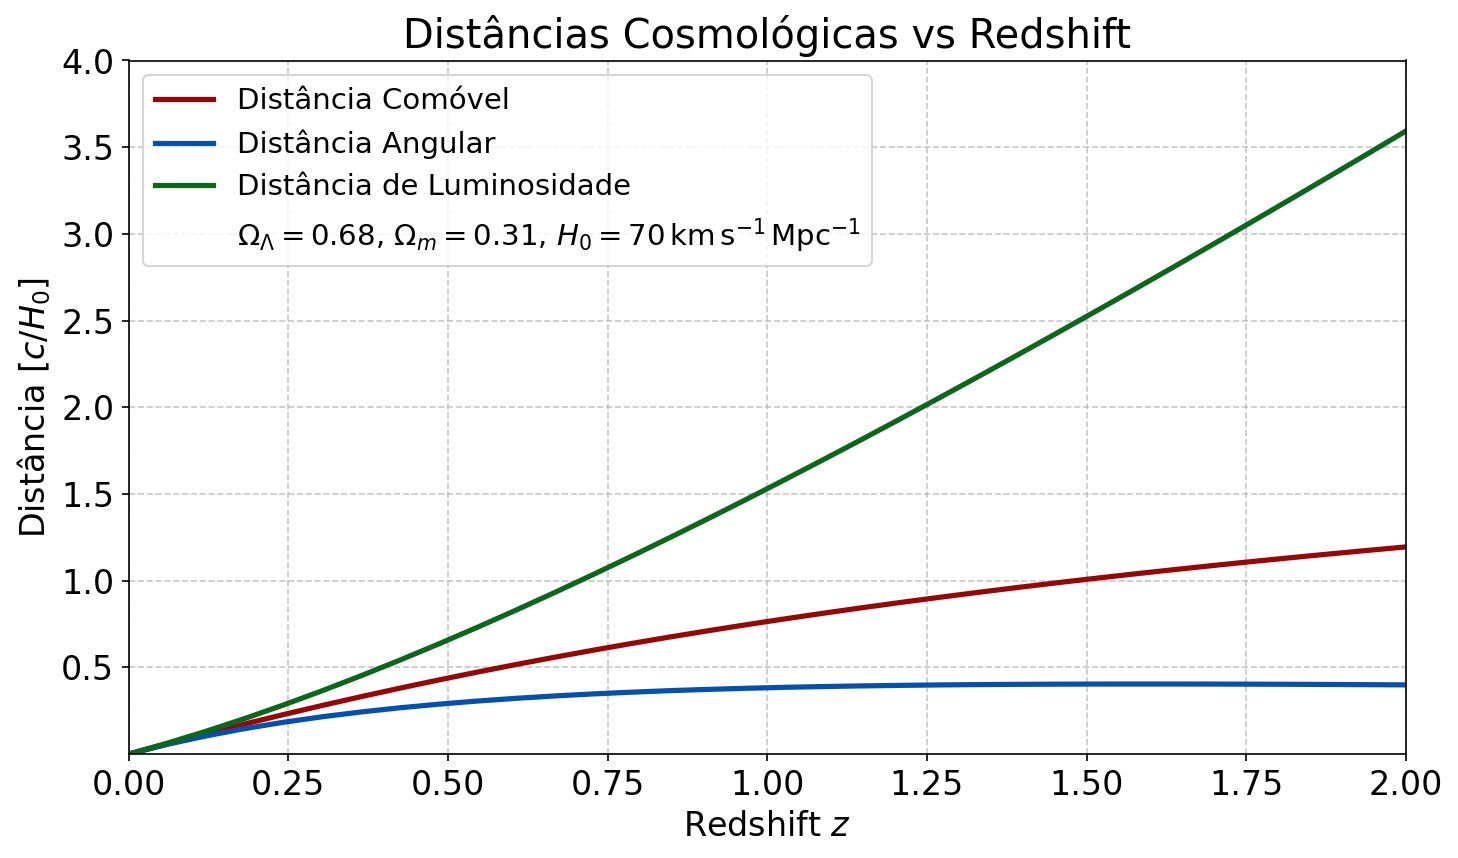

In [24]:
z_list, dc_list, da_list, dl_list, H0, Omega_b, Omega_c,  Omega_x  = distance()
Omega_m = Omega_b+Omega_c

plt.rcParams.update({
    'font.size': 16,
})

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#960707", "#0450ac", "#0c671d"]

ax.plot(z_list, dc_list, label='Distância Comóvel',
        color=colors[0], linewidth=2.5)

ax.plot(z_list, da_list, label='Distância Angular',
        color=colors[1], linewidth=2.5)

ax.plot(z_list, dl_list, label=r'Distância de Luminosidade',
        color=colors[2], linewidth=2.5)

ax.set_xlabel(r'Redshift $z$')
ax.set_ylabel(r'Distância $[c/H_0]$')
ax.set_title('Distâncias Cosmológicas vs Redshift')

ax.set_xlim(0, 2.0)
ax.set_ylim(0.0001, 4)

label_params = (
    r'$\Omega_\Lambda=%.2f$, $\Omega_m=%.2f$, '
    r'$H_0=%d\,\mathrm{km\,s^{-1}\,Mpc^{-1}}$'
) % (Omega_x, Omega_m, H0)

ax.plot([], [], ' ', label=label_params)

ax.legend(
    frameon=True,
    facecolor='white', 
    edgecolor='0.7',  
    framealpha=1.0,
)
ax.legend(loc='upper left')
ax.legend(fontsize=14)

ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()